# Data Analysis Mathematics, Algorithms and Modeling

## Team Information - **Group Presentation 5**

**Team Members**

Name: Ayush Patel  
Student Number: 9033358

Name: Nikhil Shankar  
Student Number: 9026254

Name: Sreehari Prathap  
Student Number: 8903199


## Step 1: Install and Configure the IDE (e.g., Jupyter Notebook and VS Code)
- Install Anaconda (for Jupyter Notebook) and Visual Studio Code (VS Code).
  - Anaconda: Visit [anaconda.com](https://www.anaconda.com/products/individual) and download the appropriate installer for your operating system.
  - VS Code: Download and install from [Visual Studio Code](https://code.visualstudio.com/).
- Install Pandas Library
  - Open the terminal and run the following command: `pip install pandas`

## Step 2: Downloading the Dataset
We are using the Employee performance dataset from [Kaggle], which can be downloaded directly via the link:
- URL: [https://www.kaggle.com/datasets/mexwell/employee-performance-and-productivity-data]

Our dataset contains workplace information for employees, including productivity metrics like performance scores, salary, and satisfaction, along with demographic data like gender, age, and department. We're investigating whether gender or other factors influence workplace outcomes like promotions, salaries, and satisfaction.

## Step 3 : Hypothesis

## Revised Hypothesis
The dataset focuses on examining potential biases in salary based on age, gender, and education levels. The goal is to identify whether these factors significantly influence salary disparities.


## Hypothesis:

Null Hypothesis (H₀): Age, gender, and education level do not interact to significantly influence salary.

Alternative Hypothesis (H₁): Age, gender, and education level interact to significantly influence salary.

### Data preprocessing and cleaning along with methods for EDA

In [36]:

import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

class LinearRegressionPipeline:
    def __init__(self, data):
        # Ensure data is a Pandas DataFrame
        if isinstance(data, pd.DataFrame):
            self.data = data
        else:
            raise ValueError("Provided data is not a Pandas DataFrame")
        self.model = None
        self.X = None
        self.y = None
        self.scaler = StandardScaler()

    def load_data(self):
        """Loads data into the pipeline."""
        # Check the first few rows to verify structure
        print("Data loaded successfully. Here are the first few rows:")
        print(self.data.head())
        return self.data

    def clean_data(self):
        """Cleans the data by selecting relevant columns and removing any missing values."""
        # Check if data is a DataFrame
        if not isinstance(self.data, pd.DataFrame):
            raise ValueError("Data is not a Pandas DataFrame. Please check the data source.")
        
        # Check columns in the dataset
        print(f"Columns available in the dataset: {self.data.columns.tolist()}")

        # Convert Gender to numerical format: Male = 1, Female = 2
        self.data['Gender'] = self.data['Gender'].map({'Male': 1, 'Female': 2})
        
        # Replace similar education levels to have uniformity using .loc
        self.data.loc[:, 'Education Level'] = self.data['Education Level'].replace({
            "Bachelor's Degree": "Bachelor's",
            "Master's Degree": "Master's",
            "PhD": "phD"
        })

        # Drop rows with missing values
        self.data.dropna(inplace=True)

        # Optionally, check for duplicates
        self.data.drop_duplicates(inplace=True)

        print(f"Data cleaned with shape: {self.data.shape}")
        return self.data

    def remove_outliers(self, columns, method='iqr'):
        """
        Removes outliers from the dataset for the specified columns using the chosen method.
        :param columns: List of column names to check for outliers.
        :param method: Method for outlier detection ('iqr' or 'zscore').
        """
        if method == 'iqr':
            for col in columns:
                Q1 = self.data[col].quantile(0.25)
                Q3 = self.data[col].quantile(0.75)
                IQR = Q3 - Q1
                lower_bound = Q1 - 1.5 * IQR
                upper_bound = Q3 + 1.5 * IQR
                # Filter out rows with outliers
                self.data = self.data[(self.data[col] >= lower_bound) & (self.data[col] <= upper_bound)]
        elif method == 'zscore':
            from scipy.stats import zscore
            # Calculate Z-scores for the specified columns
            z_scores = np.abs(zscore(self.data[columns]))
            self.data = self.data[(z_scores < 3).all(axis=1)]  # Remove rows where any z-score > 3
        else:
            raise ValueError("Method must be either 'iqr' or 'zscore'.")

        print(f"Outliers removed. Data now has shape: {self.data.shape}")
        return self.data

    def split_data_based_on_gender(self):
        """Splits the data based on Gender: 1 = Male and 2 = Female."""
        male_data = self.data[self.data['Gender'] == 1]
        female_data = self.data[self.data['Gender'] == 2]

        print(f"Male data count: {male_data.shape[0]}")
        print(f"Female data count: {female_data.shape[0]}")

        return male_data, female_data

    def train_model(self, feature_columns, target_column):
        """
        Trains a linear regression model.
        :param feature_columns: List of feature column names.
        :param target_column: Name of the target column.
        """
        self.X = self.data[feature_columns]
        self.y = self.data[target_column]

        # Standardize features
        self.X = self.scaler.fit_transform(self.X)

        # Train linear regression model
        self.model = LinearRegression()
        self.model.fit(self.X, self.y)

        # Model coefficients and intercept
        print("Model trained successfully.")
        print(f"Coefficients: {self.model.coef_}")
        print(f"Intercept: {self.model.intercept_}")

        return self.model

    def evaluate_model(self):
        """
        Evaluates the trained model.
        """
        if self.model is None:
            raise ValueError("Model has not been trained yet.")

        y_pred = self.model.predict(self.X)

        # Calculate evaluation metrics
        mse = mean_squared_error(self.y, y_pred)
        r2 = r2_score(self.y, y_pred)

        print(f"Model evaluation metrics:\nMean Squared Error: {mse}\nR^2 Score: {r2}")
        return mse, r2



In [37]:
# Usage
file_path = '../data/Salary_Data.csv'  # Path to your dataset

# Load the dataset into a Pandas DataFrame
data = pd.read_csv(file_path)

# print unique values of each column not as a function
print("Unique values of each column")
for col in data.columns:
    print(f"{col}: {data[col].unique()}")
    print()
    

# Create an instance of the pipeline class
pipeline = LinearRegressionPipeline(data)

# Run the steps in the pipeline
pipeline.load_data()
pipeline.clean_data()


Unique values of each column
Age: [32. 28. 45. 36. 52. 29. 42. 31. 26. 38. 48. 35. 40. 27. 44. 33. 39. 25.
 51. 34. 47. 30. 41. 37. 24. 43. 50. 46. 49. 23. 53. nan 61. 57. 62. 55.
 56. 54. 60. 58. 22. 21.]

Gender: ['Male' 'Female' nan 'Other']

Education Level: ["Bachelor's" "Master's" 'PhD' nan "Bachelor's Degree" "Master's Degree"
 'High School' 'phD']

Job Title: ['Software Engineer' 'Data Analyst' 'Senior Manager' 'Sales Associate'
 'Director' 'Marketing Analyst' 'Product Manager' 'Sales Manager'
 'Marketing Coordinator' 'Senior Scientist' 'Software Developer'
 'HR Manager' 'Financial Analyst' 'Project Manager' 'Customer Service Rep'
 'Operations Manager' 'Marketing Manager' 'Senior Engineer'
 'Data Entry Clerk' 'Sales Director' 'Business Analyst' 'VP of Operations'
 'IT Support' 'Recruiter' 'Financial Manager' 'Social Media Specialist'
 'Software Manager' 'Junior Developer' 'Senior Consultant'
 'Product Designer' 'CEO' 'Accountant' 'Data Scientist'
 'Marketing Specialist' 'Techni

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,1.0,Bachelor's,Software Engineer,5.0,90000.0
1,28.0,2.0,Master's,Data Analyst,3.0,65000.0
2,45.0,1.0,phD,Senior Manager,15.0,150000.0
3,36.0,2.0,Bachelor's,Sales Associate,7.0,60000.0
4,52.0,1.0,Master's,Director,20.0,200000.0
...,...,...,...,...,...,...
6623,43.0,2.0,Master's,Digital Marketing Manager,15.0,150000.0
6624,27.0,1.0,High School,Sales Manager,2.0,40000.0
6625,33.0,2.0,Bachelor's,Director of Marketing,8.0,80000.0
6628,37.0,1.0,Bachelor's,Sales Director,7.0,90000.0


## Step 4 : Implement Simple Linear Regression (SLR)

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression

def remove_zero_values(self):
    """Removes rows with zero values from the dataset."""
    self.data = self.data[(self.data != 0).all(axis=1)]
    print(f"Zero values removed. Data now has shape: {self.data.shape}")
    return self.data

# Add method to class
LinearRegressionPipeline.remove_zero_values = remove_zero_values

def plot_slr(self, x_col, y_col):
    """Plots Simple Linear Regression for whole dataset, male dataset, and female dataset."""
    # Create the Linear Regression model
    model = LinearRegression()

    # Create subplots
    fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

    # Plot for the whole dataset
    sns.regplot(ax=axes[0], x=x_col, y=y_col, data=self.data, scatter_kws={'color':'blue'}, line_kws={'color':'red'})
    axes[0].set_title('Whole Dataset')
    axes[0].set_xlabel(x_col)
    axes[0].set_ylabel(y_col)

    # Plot for Male dataset
    male_data = self.data[self.data['Gender'] == 1]  # Assuming 1 = Male
    sns.regplot(ax=axes[1], x=x_col, y=y_col, data=male_data, scatter_kws={'color':'green'}, line_kws={'color':'green'})
    axes[1].set_title('Male Dataset')
    axes[1].set_xlabel(x_col)

    # Plot for Female dataset
    female_data = self.data[self.data['Gender'] == 2]  # Assuming 2 = Female
    sns.regplot(ax=axes[2], x=x_col, y=y_col, data=female_data, scatter_kws={'color':'purple'}, line_kws={'color':'purple'})
    axes[2].set_title('Female Dataset')
    axes[2].set_xlabel(x_col)

    # Adjust layout
    plt.tight_layout()
    plt.show()
    

# function to plot simple linear regression for education level
def plot_slr_education(self, x_col, y_col):
    """Plots Simple Linear Regression
    for whole
    dataset"""
    # Create the Linear Regression model
    model = LinearRegression()

    # Get unique education levels
    education_levels = self.data['Education Level'].unique()
    
    # Create subplots
    fig, axes = plt.subplots(1, len(education_levels) + 1, figsize=(18, 6), sharey=True)

    # Plot for the whole dataset
    sns.regplot(ax=axes[0], x=x_col, y=y_col, data=self.data, scatter_kws={'color':'blue'}, line_kws={'color':'red'})
    axes[0].set_title('Whole Dataset')
    axes[0].set_xlabel(x_col)
    axes[0].set_ylabel(y_col)
    
    # Plot for each education level
    for i, level in enumerate(education_levels, start=1):
        level_data = self.data[self.data['Education Level'] == level]
        sns.regplot(ax=axes[i], x=x_col, y=y_col, data=level_data, scatter_kws={'color':'green'}, line_kws={'color':'green'})
        axes[i].set_title(f"{level} Dataset")
        axes[i].set_xlabel(x_col)
    
    # Adjust layout
    plt.tight_layout()
    plt.show()

# Add method to class
LinearRegressionPipeline.plot_slr = plot_slr
LinearRegressionPipeline.plot_slr_education = plot_slr_education



Zero values removed. Data now has shape: (1759, 6)


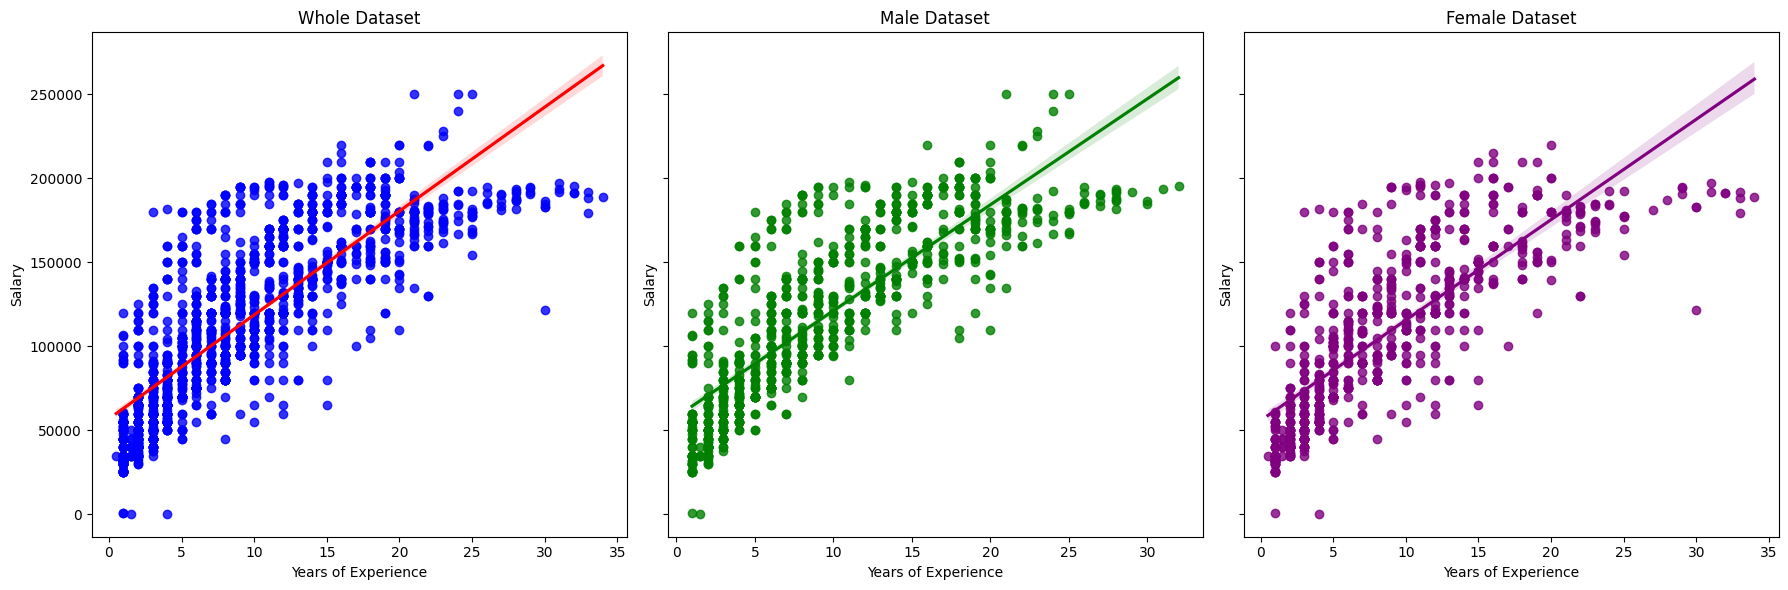

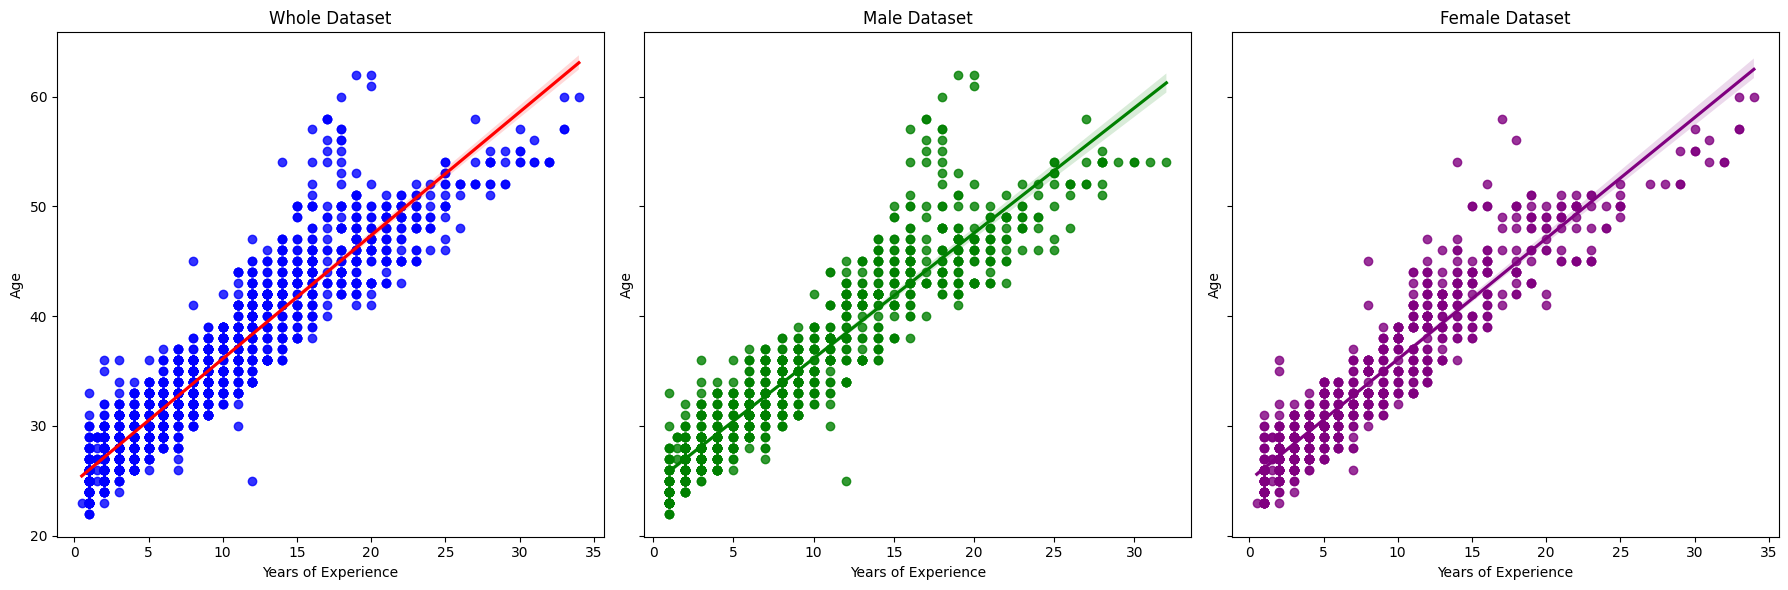

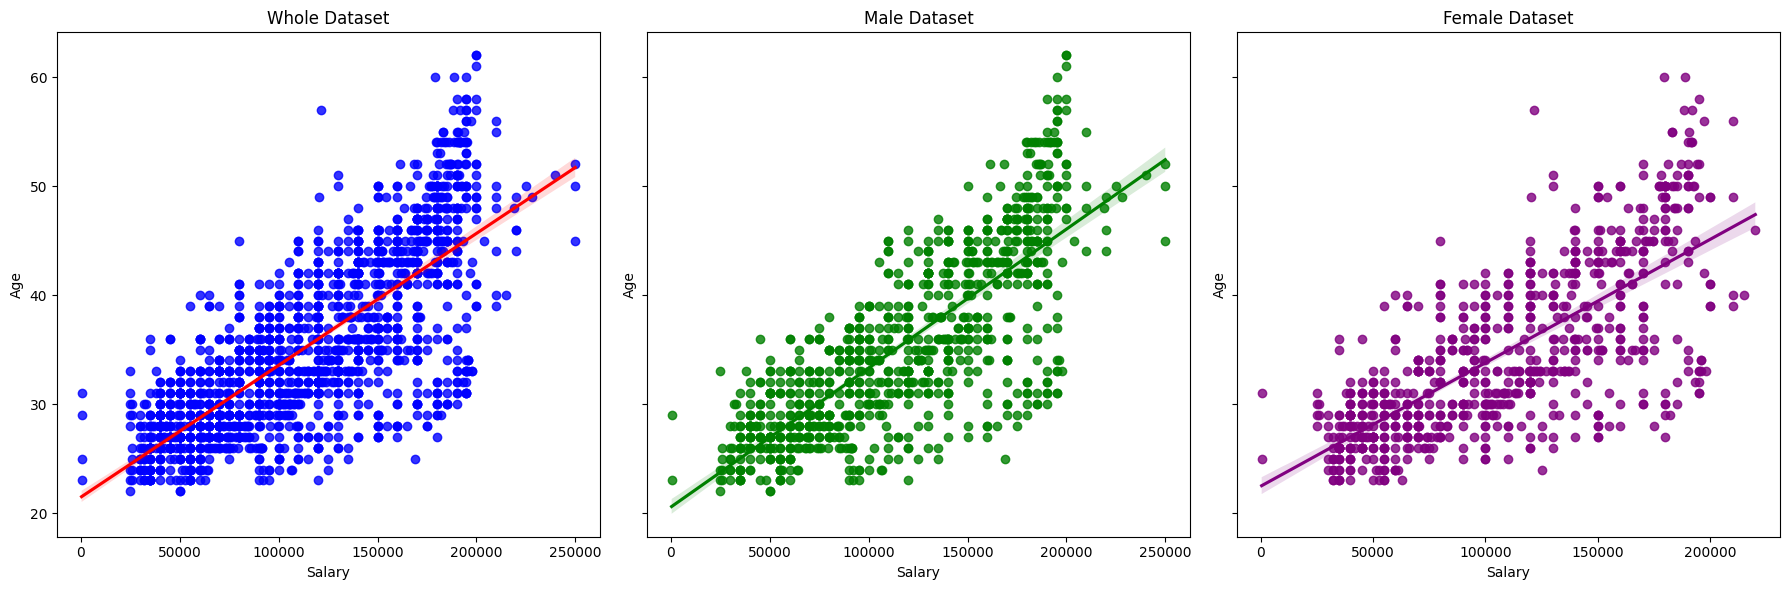

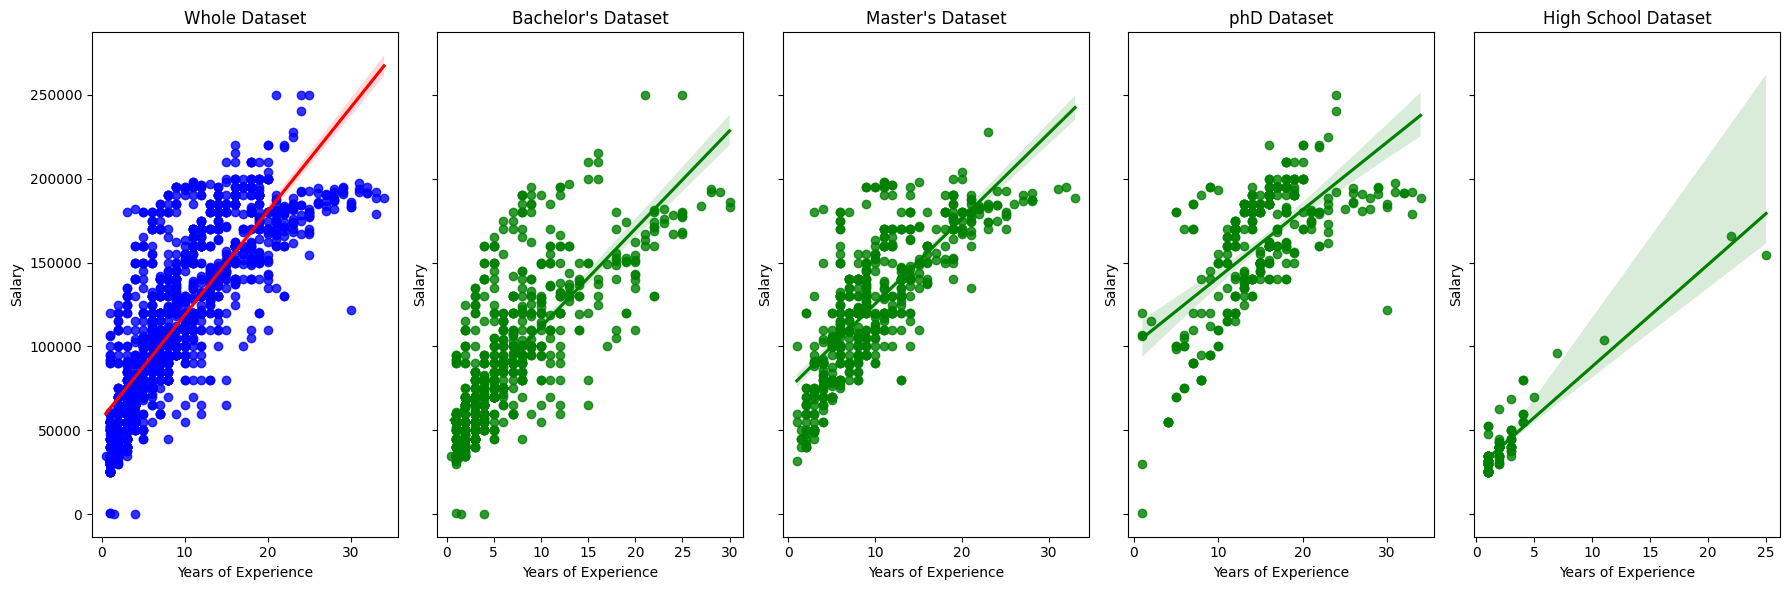

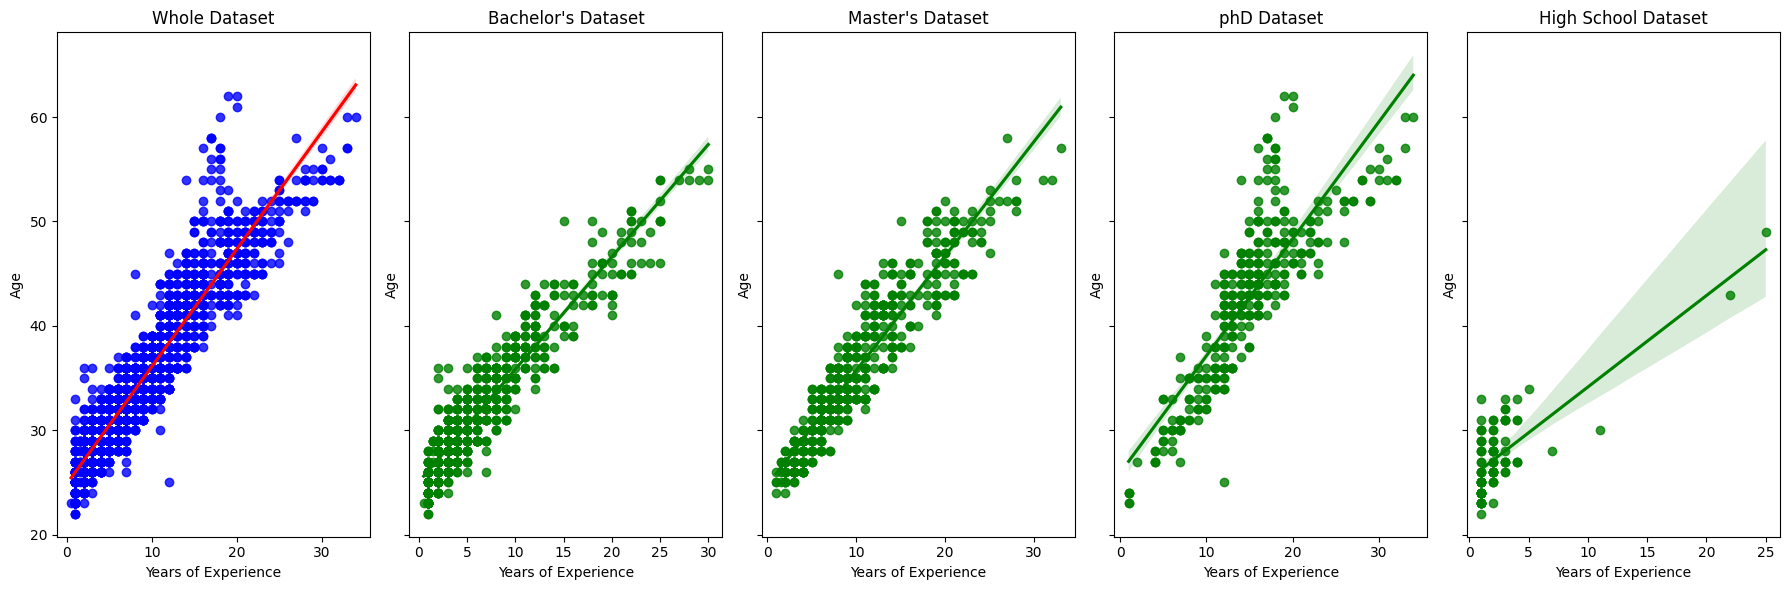

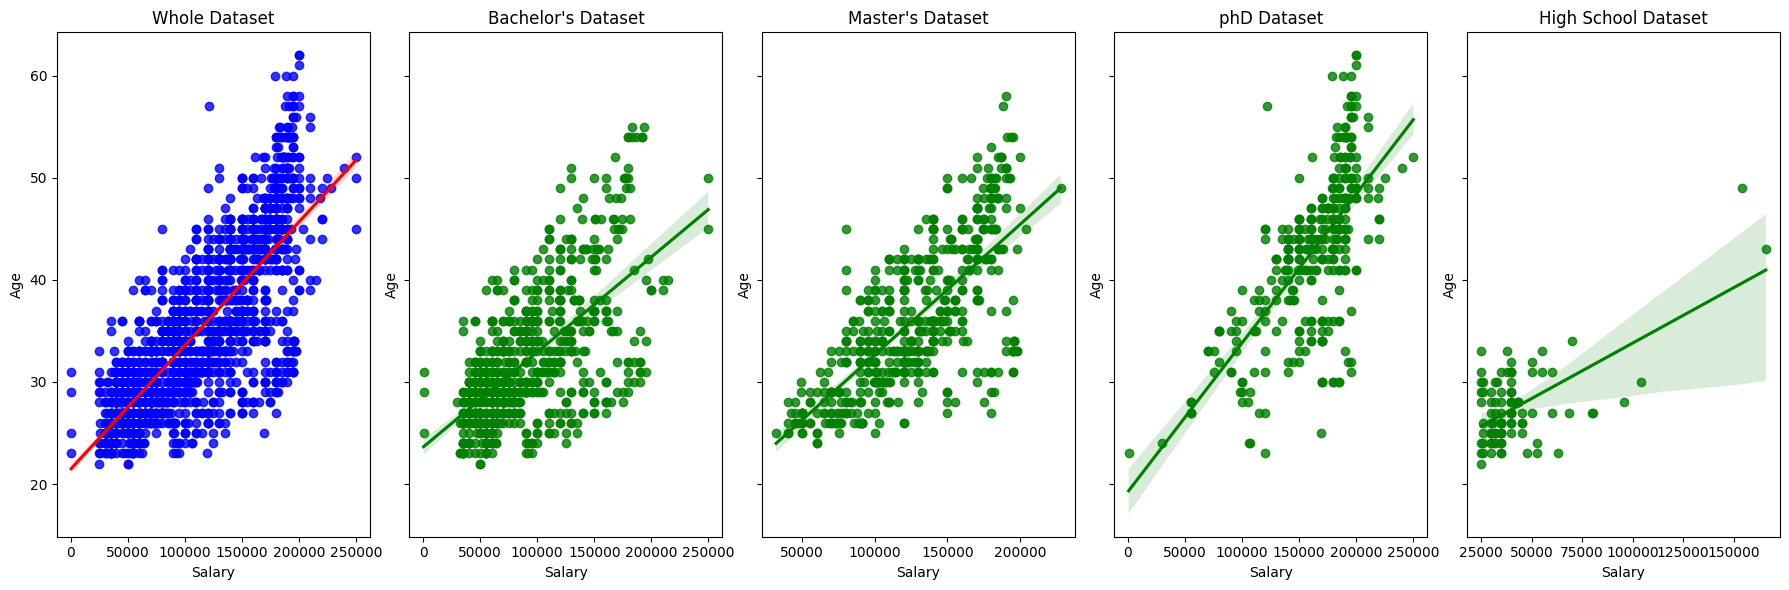

In [39]:
pipeline.remove_zero_values()
pipeline.plot_slr('Years of Experience', 'Salary')
pipeline.plot_slr('Years of Experience', 'Age')
pipeline.plot_slr('Salary', 'Age')

pipeline.plot_slr_education('Years of Experience', 'Salary')
pipeline.plot_slr_education('Years of Experience', 'Age')
pipeline.plot_slr_education('Salary', 'Age')

in the graph for experience and salary levels , the male dataset seems to show slightly higher salaries than the female dataset for similar experience levels, suggesting potential gender-based salary disparities.

Bachelor's and Master's degree holders display steady salary growth with age but less variation than PhD holders. The high school dataset's wider confidence interval suggests inconsistent salary trends. Together with the earlier findings, it becomes clear that higher education levels not only boost salary growth with experience but also ensure better pay at different ages, underlining the importance of education for career and financial growth



## Step 5 : Analysis
### Homoscedasticity

In [40]:
def check_homoscedasticity(self):
    """
    Checks for homoscedasticity by plotting residuals against predicted values.
    """
    if self.model is None:
        raise ValueError("Model has not been trained yet. Please train the model using 'train_model' before checking homoscedasticity.")
    
    # Predict values and calculate residuals
    y_pred = self.model.predict(self.X)
    residuals = self.y - y_pred

    # Plot residuals against predicted values
    plt.scatter(y_pred, residuals, alpha=0.5)
    plt.axhline(y=0, color='red', linestyle='--')
    plt.xlabel('Predicted Values')
    plt.ylabel('Residuals')
    plt.title('Residuals vs. Predicted Values')
    plt.show()

    print("If residuals are randomly scattered around 0, homoscedasticity assumption holds.")

def calculate_r_squared(self):
    """
    Calculates and prints the R-squared value for the model.
    """
    if self.model is None:
        raise ValueError("Model has not been trained yet.")
    
    y_pred = self.model.predict(self.X)
    r2 = r2_score(self.y, y_pred)
    
    print(f"R-Squared Value: {r2}")
    print("Higher R-squared indicates better fit.")
    return r2

LinearRegressionPipeline.check_homoscedasticity = check_homoscedasticity
LinearRegressionPipeline.calculate_r_squared = calculate_r_squared


Model trained successfully.
Coefficients: [38870.27049419 -2792.91301026]
Intercept: 114036.28823194996


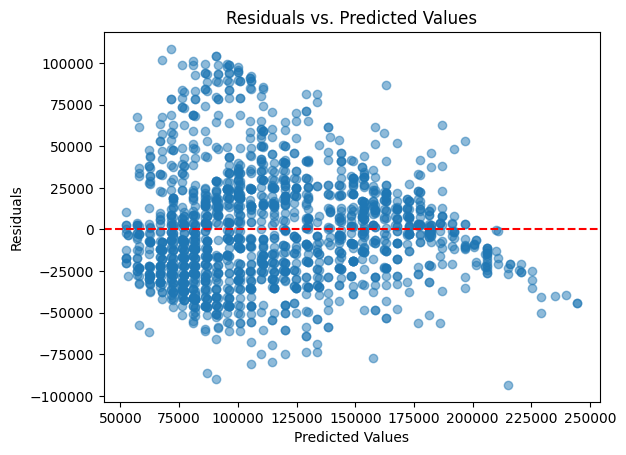

If residuals are randomly scattered around 0, homoscedasticity assumption holds.


In [41]:
# Train the model first
pipeline.train_model(feature_columns=['Age', 'Gender'], target_column='Salary')

# Check homoscedasticity
pipeline.check_homoscedasticity()

### R-Squared

In [42]:
# Calculate R-squared
r2 = pipeline.calculate_r_squared()
print(f"R-Squared Value: {r2}")

R-Squared Value: 0.5831501782589279
Higher R-squared indicates better fit.
R-Squared Value: 0.5831501782589279


### Summary
The residuals vs. predicted values plot shows that the residuals (errors) are scattered, but there appears to be some pattern, indicating potential heteroscedasticity. This means the model might not fully satisfy the assumption of constant variance in errors (homoscedasticity).

The R-squared value, 0.583, suggests that about 58.3% of the variability in the target variable (Salary) is explained by the model, indicating a moderate fit. While the model captures a significant portion of the variability, there may still be room for improvement. The scattered pattern and moderate R-squared highlight potential issues to address for better predictions and model reliability.